# Advanced Ensemble Model — World Cup Win Prediction

**Dataset:** `class_a_squad_2006_2022.csv` — 313 matches × 183 columns (2006–2022)  
**Target:** `y_win` — 1 if home team wins, 0 otherwise (47% / 53% split)  

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# scikit-learn
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# LightGBM
import lightgbm as lgb

# Optuna
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

# Paths
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "final"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

Project root: /Users/ogechukwuezenwa/Documents/Duke_University_Projects/Spring_2026/IDS-705_Machine_Learning_Principles/IDS_705_Final
Data dir:     /Users/ogechukwuezenwa/Documents/Duke_University_Projects/Spring_2026/IDS-705_Machine_Learning_Principles/IDS_705_Final/data/final


## Load Data & Define Features

In [2]:
df = pd.read_csv(DATA_DIR / "class_a_squad_2006_2022.csv")
print(f"Shape: {df.shape}")
print(f'Years: {sorted(df["year"].unique())}')
print(f'Target: y_win — {dict(df["y_win"].value_counts())}')

Shape: (313, 183)
Years: [np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
Target: y_win — {0: np.int64(165), 1: np.int64(148)}


In [3]:
# Feature columns
# Drop identifiers, target, and string columns
NON_FEATURES = [
    "match_id",
    "tournament_id",
    "year",
    "home_team_id",
    "away_team_id",
    "y_win",
    "stage_name",
    "group_name",
    "group_stage",
    "knockout_stage",
    "replayed",
    "replay",
]

ALL_FEAT_COLS = [
    c for c in df.columns if c not in NON_FEATURES and df[c].dtype != object
]

print(f"Total candidate features: {len(ALL_FEAT_COLS)}")

# NaN summary
nan_pct = df[ALL_FEAT_COLS].isna().mean().sort_values(ascending=False)
print(f"\nFeatures with >30% missing:")
print(nan_pct[nan_pct > 0.30].to_string())

Total candidate features: 171

Features with >30% missing:
feat_away_mgr_hist_win_rate_shrunk    0.664537
feat_home_mgr_hist_win_rate_shrunk    0.619808
away_hist_pso_win_rate_shrunk         0.507987
home_hist_pso_win_rate_shrunk         0.408946


In [4]:
# Drop features with >50% missing — too sparse to be useful
DROP_SPARSE = nan_pct[nan_pct > 0.50].index.tolist()
FEAT_COLS = [c for c in ALL_FEAT_COLS if c not in DROP_SPARSE]
print(f"Dropped {len(DROP_SPARSE)} sparse features: {DROP_SPARSE}")
print(f"Remaining features: {len(FEAT_COLS)}")

X = df[FEAT_COLS].copy()
y = df["y_win"].values
years = df["year"].values
TOURNAMENT_YEARS = sorted(df["year"].unique())

Dropped 3 sparse features: ['feat_away_mgr_hist_win_rate_shrunk', 'feat_home_mgr_hist_win_rate_shrunk', 'away_hist_pso_win_rate_shrunk']
Remaining features: 168


## Leave-One-Tournament-Out (LOTO) CV Helper

In [5]:
def loto_splits(years_arr, tournament_years=TOURNAMENT_YEARS):
    """Yield (train_idx, test_idx) for each tournament year."""
    for yr in tournament_years:
        test_idx = np.where(years_arr == yr)[0]
        train_idx = np.where(years_arr != yr)[0]
        yield yr, train_idx, test_idx


def make_pipeline(clf):
    """Wrap any classifier in an impute → scale → model pipeline."""
    return Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", clf),
        ]
    )


def eval_loto(pipeline, X, y, years_arr, proba=True):
    """
    Run LOTO-CV and return:
      - oof_preds: predicted probabilities (or decisions) for every row
      - per-fold accuracy, AUC, log-loss
    """
    oof_proba = np.full(len(y), np.nan)
    fold_results = []

    for yr, train_idx, test_idx in loto_splits(years_arr):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        pipeline.fit(X_tr, y_tr)

        if proba:
            p = pipeline.predict_proba(X_te)[:, 1]
        else:
            # RidgeClassifier has no predict_proba — use decision_function
            d = pipeline.decision_function(X_te)
            p = (d - d.min()) / (d.max() - d.min() + 1e-9)  # min-max to [0,1]

        oof_proba[test_idx] = p
        preds = (p >= 0.5).astype(int)

        fold_results.append(
            {
                "year": yr,
                "n": len(y_te),
                "acc": accuracy_score(y_te, preds),
                "auc": roc_auc_score(y_te, p),
                "logloss": log_loss(y_te, p),
            }
        )

    return oof_proba, pd.DataFrame(fold_results)


def summary_row(name, oof_proba, y, fold_df):
    preds = (oof_proba >= 0.5).astype(int)
    return {
        "Model": name,
        "OOF Acc": f"{accuracy_score(y, preds):.3f}",
        "OOF AUC": f"{roc_auc_score(y, oof_proba):.3f}",
        "OOF LogLoss": f"{log_loss(y, oof_proba):.3f}",
        "Fold Acc μ±σ": f"{fold_df['acc'].mean():.3f}±{fold_df['acc'].std():.3f}",
    }

## Baseline: Logistic Regression

In [6]:
lr_pipe = make_pipeline(LogisticRegression(max_iter=1000, C=0.1, random_state=42))
lr_oof, lr_folds = eval_loto(lr_pipe, X, y, years)

print("Logistic Regression — LOTO-CV")
print(lr_folds.to_string(index=False))
print(f"\nOverall OOF Acc:  {accuracy_score(y, (lr_oof>=0.5).astype(int)):.3f}")
print(f"Overall OOF AUC:  {roc_auc_score(y, lr_oof):.3f}")

Logistic Regression — LOTO-CV
 year  n      acc      auc  logloss
 2006 62 0.580645 0.743697 0.728979
 2010 63 0.682540 0.696842 0.685109
 2014 64 0.625000 0.695015 0.815093
 2018 63 0.650794 0.682952 0.762015
 2022 61 0.590164 0.600216 0.947575

Overall OOF Acc:  0.626
Overall OOF AUC:  0.667


## Feature Selection via SHAP

In [ ]:
# Impute before fitting LightGBM for SHAP
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=FEAT_COLS)

lgb_selector = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
lgb_selector.fit(X_imp, y)

# SHAP values
explainer = shap.TreeExplainer(lgb_selector)
shap_values = explainer.shap_values(X_imp)

# Handle output: shap_values may be list [class0, class1] or 3-D array
if isinstance(shap_values, list):
    sv = shap_values[1]  # class-1 SHAP values
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEAT_COLS).sort_values(
    ascending=False
)

TOP_N = 25
TOP_FEATURES = mean_abs_shap.head(TOP_N).index.tolist()
print(f"Top {TOP_N} features by mean |SHAP|:")
print(mean_abs_shap.head(TOP_N).to_string())

Top 25 features by mean |SHAP|:
feat_elo_rating_diff                  0.751193
home_squad_fwd_avg_assists            0.618448
home_squad_avg_appearances            0.375326
home_squad_gk_avg_clean_sheets        0.342956
home_squad_fwd_avg_minutes            0.320289
feat_squad_gk_clean_sheets_diff       0.317371
home_squad_n_fw                       0.211934
home_hist_et_rate                     0.204520
stadium_capacity                      0.203322
feat_hist_goal_diff_per_match_diff    0.193506
away_squad_age_std                    0.185502
home_squad_n_clubs                    0.183212
home_squad_mid_avg_goals              0.182113
feat_squad_age_mean_diff              0.180332
feat_squad_goals_diff                 0.170332
away_squad_avg_minutes                0.159817
away_hist_et_rate                     0.155857
feat_squad_assists_diff               0.143190
away_fifa_points                      0.137614
away_squad_def_avg_goals              0.130775
home_squad_fwd_avg_goals    

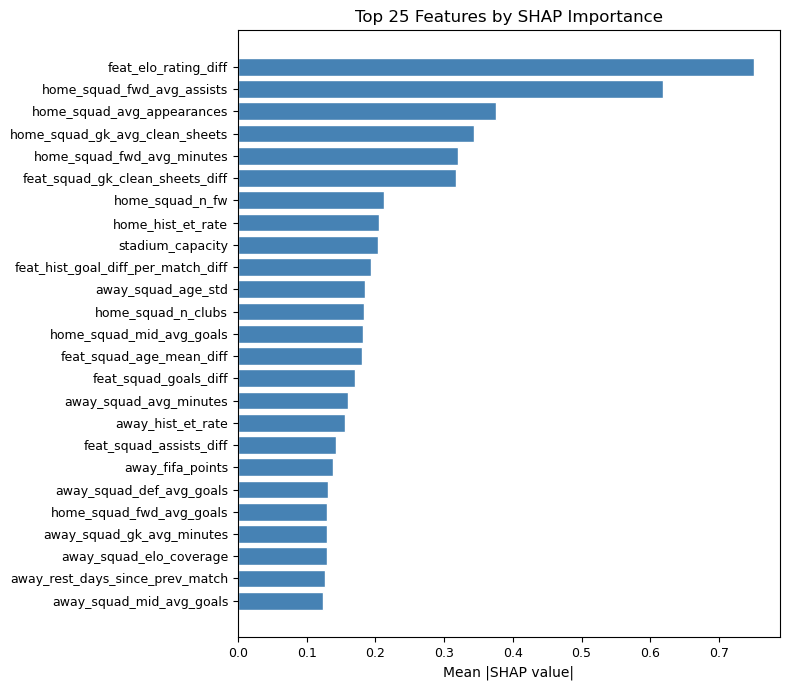

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
top_shap = mean_abs_shap.head(TOP_N).sort_values()
ax.barh(top_shap.index, top_shap.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Top {TOP_N} Features by SHAP Importance")
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [9]:
# Subset data to top features
X_top = X[TOP_FEATURES].copy()
print(f"Feature matrix after selection: {X_top.shape}")

Feature matrix after selection: (313, 25)


## LightGBM with Optuna Hyperparameter Tuning

In [10]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 40),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state": 42,
        "verbose": -1,
    }

    aucs = []
    for _, train_idx, test_idx in loto_splits(years):
        X_tr = X_top.iloc[train_idx]
        X_te = X_top.iloc[test_idx]
        y_tr = y[train_idx]
        y_te = y[test_idx]

        imp_ = SimpleImputer(strategy="median")
        X_tr_imp = imp_.fit_transform(X_tr)
        X_te_imp = imp_.transform(X_te)

        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr_imp, y_tr)
        p = clf.predict_proba(X_te_imp)[:, 1]
        aucs.append(roc_auc_score(y_te, p))

    return np.mean(aucs)


print("Running Optuna search (50 trials)...")
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_PARAMS["random_state"] = 42
BEST_PARAMS["verbose"] = -1
print(f"\nBest LOTO-CV AUC: {study.best_value:.4f}")
print(f"Best params: {BEST_PARAMS}")

Running Optuna search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best LOTO-CV AUC: 0.8312
Best params: {'n_estimators': 125, 'learning_rate': 0.07334719825422695, 'num_leaves': 33, 'min_child_samples': 17, 'subsample': 0.9174242452716824, 'colsample_bytree': 0.6653718096831271, 'reg_alpha': 0.003510972292332193, 'reg_lambda': 0.009354646438711398, 'random_state': 42, 'verbose': -1}


In [11]:
# Evaluate tuned LightGBM with LOTO-CV
lgb_tuned_pipe = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("model", lgb.LGBMClassifier(**BEST_PARAMS)),
    ]
)
lgb_oof, lgb_folds = eval_loto(lgb_tuned_pipe, X_top, y, years)

print("Tuned LightGBM — LOTO-CV")
print(lgb_folds.to_string(index=False))
print(f"\nOverall OOF Acc:  {accuracy_score(y, (lgb_oof>=0.5).astype(int)):.3f}")
print(f"Overall OOF AUC:  {roc_auc_score(y, lgb_oof):.3f}")

Tuned LightGBM — LOTO-CV
 year  n      acc      auc  logloss
 2006 62 0.741935 0.831933 0.576691
 2010 63 0.698413 0.786316 0.624913
 2014 64 0.828125 0.914956 0.360720
 2018 63 0.793651 0.852391 0.504732
 2022 61 0.737705 0.770474 0.693836

Overall OOF Acc:  0.760
Overall OOF AUC:  0.829


## Stacking Ensemble

In [13]:
# Generate OOF predictions from each base learner
base_learners = {
    "LR": make_pipeline(LogisticRegression(max_iter=1000, C=0.1, random_state=42)),
    "LGBM": Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("model", lgb.LGBMClassifier(**BEST_PARAMS)),
        ]
    ),
    "Ridge": make_pipeline(RidgeClassifier(alpha=1.0)),
}

oof_preds = {}
for name, pipe in base_learners.items():
    proba = name != "Ridge"  # Ridge has no predict_proba
    oof, _ = eval_loto(pipe, X_top, y, years, proba=proba)
    oof_preds[name] = oof
    print(f"{name:6s} OOF AUC: {roc_auc_score(y, oof):.4f}")

# Stack OOF predictions as meta-features
meta_X = pd.DataFrame(oof_preds)

LR     OOF AUC: 0.7317
LGBM   OOF AUC: 0.8295
Ridge  OOF AUC: 0.7182


In [ ]:
# Train meta-learner via LOTO-CV on stacked predictions
meta_oof = np.full(len(y), np.nan)
meta_folds = []

for yr, train_idx, test_idx in loto_splits(years):
    meta_tr = meta_X.iloc[train_idx].values
    meta_te = meta_X.iloc[test_idx].values
    y_tr = y[train_idx]
    y_te = y[test_idx]

    meta_clf = LogisticRegression(C=1.0, max_iter=500, random_state=42)
    meta_clf.fit(meta_tr, y_tr)
    p = meta_clf.predict_proba(meta_te)[:, 1]
    meta_oof[test_idx] = p

    meta_folds.append(
        {
            "year": yr,
            "n": len(y_te),
            "acc": accuracy_score(y_te, (p >= 0.5).astype(int)),
            "auc": roc_auc_score(y_te, p),
            "logloss": log_loss(y_te, p),
        }
    )

meta_folds_df = pd.DataFrame(meta_folds)
print("Stacking Ensemble — LOTO-CV")
print(meta_folds_df.to_string(index=False))
print(f"\nOverall OOF Acc:  {accuracy_score(y, (meta_oof>=0.5).astype(int)):.3f}")
print(f"Overall OOF AUC:  {roc_auc_score(y, meta_oof):.3f}")

Stacking Ensemble — LOTO-CV
 year  n      acc      auc  logloss
 2006 62 0.741935 0.834034 0.540941
 2010 63 0.698413 0.784211 0.574617
 2014 64 0.828125 0.912023 0.439492
 2018 63 0.777778 0.838877 0.504792
 2022 61 0.754098 0.758621 0.574279

Overall OOF Acc:  0.760
Overall OOF AUC:  0.813


## Model Comparison

                         Model OOF Acc OOF AUC OOF LogLoss Fold Acc μ±σ
Logistic Regression (baseline)   0.626   0.667       0.787  0.626±0.042
              LightGBM (tuned)   0.760   0.829       0.551  0.760±0.051
             Stacking Ensemble   0.760   0.813       0.526  0.760±0.048


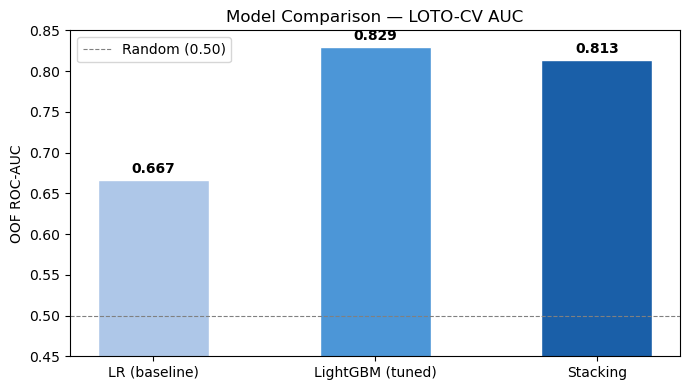

In [15]:
results = [
    summary_row("Logistic Regression (baseline)", lr_oof, y, lr_folds),
    summary_row("LightGBM (tuned)", lgb_oof, y, lgb_folds),
    summary_row("Stacking Ensemble", meta_oof, y, meta_folds_df),
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Quick AUC bar chart
aucs = [
    ("LR (baseline)", roc_auc_score(y, lr_oof)),
    ("LightGBM (tuned)", roc_auc_score(y, lgb_oof)),
    ("Stacking", roc_auc_score(y, meta_oof)),
]
names, vals = zip(*aucs)
colors = ["#aec7e8", "#4c96d7", "#1a5fa8"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, vals, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0.45, 0.85)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Random (0.50)")
for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel("OOF ROC-AUC")
ax.set_title("Model Comparison — LOTO-CV AUC")
ax.legend()
plt.tight_layout()
plt.show()

## ROC Curves

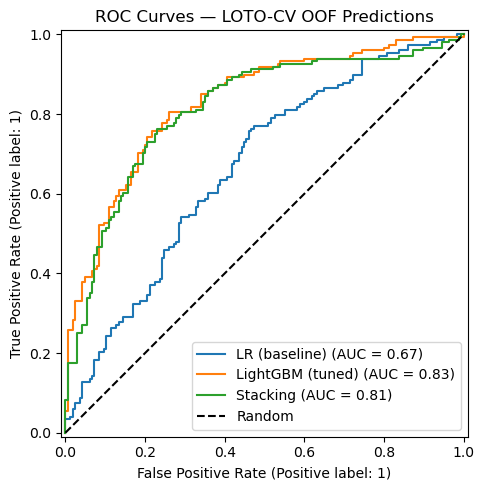

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, oof in [
    ("LR (baseline)", lr_oof),
    ("LightGBM (tuned)", lgb_oof),
    ("Stacking", meta_oof),
]:
    RocCurveDisplay.from_predictions(y, oof, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curves — LOTO-CV OOF Predictions")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Calibration

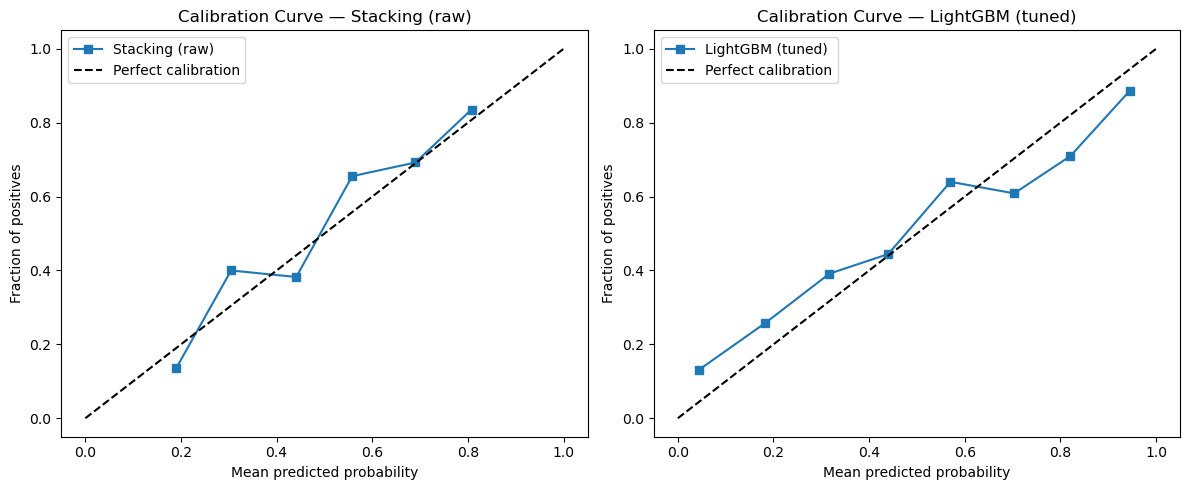

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, oof) in zip(
    axes, [("Stacking (raw)", meta_oof), ("LightGBM (tuned)", lgb_oof)]
):
    fraction_of_positives, mean_predicted_value = calibration_curve(y, oof, n_bins=8)
    ax.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration Curve — {name}")
    ax.legend()

plt.tight_layout()
plt.show()

## SHAP Interpretability on Final LightGBM

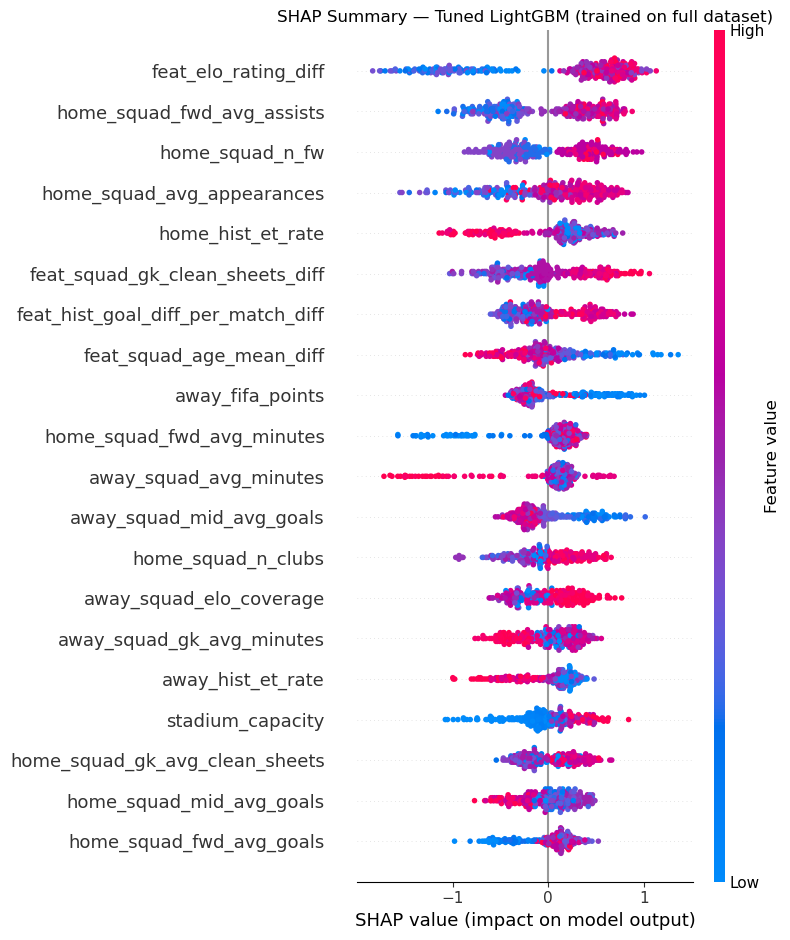

In [18]:
# Train final LightGBM on all data
imp_final = SimpleImputer(strategy="median")
X_top_imp = pd.DataFrame(imp_final.fit_transform(X_top), columns=TOP_FEATURES)

lgb_final = lgb.LGBMClassifier(**BEST_PARAMS)
lgb_final.fit(X_top_imp, y)

# SHAP
explainer_final = shap.TreeExplainer(lgb_final)
sv_final = explainer_final.shap_values(X_top_imp)

if isinstance(sv_final, list):
    sv_plot = sv_final[1]
elif sv_final.ndim == 3:
    sv_plot = sv_final[:, :, 1]
else:
    sv_plot = sv_final

# SHAP summary (beeswarm)
plt.figure(figsize=(9, 7))
shap.summary_plot(sv_plot, X_top_imp, plot_type="dot", show=False)
plt.title("SHAP Summary — Tuned LightGBM (trained on full dataset)")
plt.tight_layout()
plt.show()

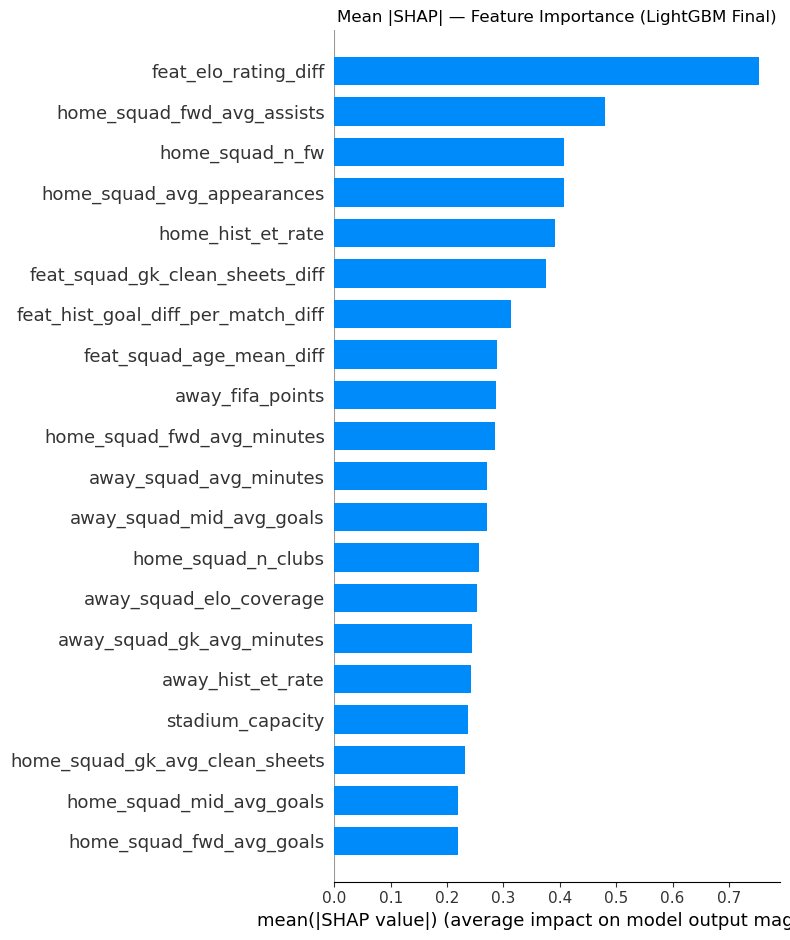

In [19]:
# SHAP bar summary
plt.figure(figsize=(8, 6))
shap.summary_plot(sv_plot, X_top_imp, plot_type="bar", show=False)
plt.title("Mean |SHAP| — Feature Importance (LightGBM Final)")
plt.tight_layout()
plt.show()